# UAV Battery Tool — Notebook 07: Log vs Simulation Comparison

Compare measured flight log voltage against a physics-based simulation that is
**fitted to the log** (same time axis, same flight phases, power matched per phase).

**Workflow:**
1. Load a real (or synthetic) flight log
2. Extract phase durations and current profile
3. Fit per-phase power estimates to match observed current
4. Run simulation with fitted power model on the same time axis
5. Overlay log and simulation voltages on one chart
6. Estimate battery sag — separate ohmic, CT and concentration components
7. Report a fitted **R_sag** parameter (effective internal resistance from sag)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats, optimize
import warnings; warnings.filterwarnings('ignore')

from batteries.database import BatteryDatabase
from batteries.log_importer import load_log, generate_synthetic_log
from mission.simulator import run_simulation
from mission.simulator import SimulationResult
from batteries.models import MissionProfile, MissionPhase

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.25})

DB_PATH = '../battery_db.xlsx'
db = BatteryDatabase(DB_PATH) if os.path.exists(DB_PATH) else BatteryDatabase()
db.load()
print(f'Database: {len(db.packs)} packs, {len(db.missions)} missions, {len(db.uav_configs)} UAVs')

Database: 8 packs, 3 missions, 3 UAVs


## 1 · Configuration

In [2]:
# ── Load settings from 00_configurator.ipynb (analysis_config.json) ───────────
import json as _json, os as _os
_CFG_PATH = _os.path.join(_os.path.dirname(_os.path.abspath('.')), 'analysis_config.json')
if not _os.path.exists(_CFG_PATH):
    _CFG_PATH = 'analysis_config.json'
_cfg = {}
if _os.path.exists(_CFG_PATH):
    with open(_CFG_PATH) as _f:
        _cfg = _json.load(_f)
    print(f'Loaded config from {_CFG_PATH}')
else:
    print('No analysis_config.json found — using defaults (run 00_configurator first)')

# ── Values from configurator ───────────────────────────────────────────────────
PACK_ID        = (_cfg.get('selected_batteries', ['BAT_MID_6S2P'])[0]
                  if isinstance(_cfg.get('selected_batteries'), list) else 'BAT_MID_6S2P')
UAV_ID         = _cfg.get('uav_id',         'HEX_SURVEY_900')
AMBIENT_TEMP_C = _cfg.get('ambient_temp_c', 25.0)

# ── Manual overrides (uncomment to override) ───────────────────────────────────
# PACK_ID        = 'BAT_MID_6S2P'
# UAV_ID         = 'HEX_SURVEY_900'
# AMBIENT_TEMP_C = 25.0

USE_SYNTHETIC = True          # True = generate log from db; False = load real file
LOG_PATH      = '../logs/your_flight.bin'   # path to real .bin / .log / .csv

pack = db.packs[PACK_ID]
uav  = db.uav_configs[UAV_ID]
print(f'Pack : {pack}')
print(f'UAV  : {uav}')

Loaded config from analysis_config.json
Pack : BAT_MID_6S2P: Mid UAV 6S2P 21700 | 6S2P | 21.9V 9.0Ah (197Wh) | 840g
UAV  : HEX_SURVEY_900: Survey Hex 900 | 11 items | 3073g total


## 2 · Load Flight Log

In [3]:
if USE_SYNTHETIC:
    # Use a reference mission profile to generate a realistic log
    REF_MISSION_ID = _cfg.get('mission_id', 'SURVEY_STD')
    ref_mission = db.missions.get(REF_MISSION_ID, list(db.missions.values())[0])
    log = generate_synthetic_log(pack, ref_mission, uav, db.discharge_pts,
                                 ambient_temp_c=AMBIENT_TEMP_C)
    print(f'Synthetic log generated from mission: {REF_MISSION_ID}')
else:
    log = load_log(LOG_PATH, pack_id=PACK_ID)
    print(f'Log loaded: {LOG_PATH}')

t   = np.array(log.time_s)
v   = np.array(log.voltage_v)
i_a = np.array(log.current_a)
soc = np.array(log.soc_pct) if log.soc_pct else np.linspace(100, 0, len(t))
temp_log = np.array(log.temp_c) if log.temp_c else np.full(len(t), AMBIENT_TEMP_C)
phases_log = np.array(log.phase_type) if log.phase_type else np.array(['UNKNOWN']*len(t))

print(f'Duration  : {t[-1]:.0f} s  ({t[-1]/60:.1f} min)')
print(f'Voltage   : {v.min():.2f} – {v.max():.2f} V')
print(f'Current   : {i_a.min():.1f} – {i_a.max():.1f} A')
print(f'SoC       : {soc.min():.1f} – {soc.max():.1f} %')
print(f'Phases    : {sorted(set(phases_log))}')

Synthetic log generated from mission: SURVEY_STD
Duration  : 1469 s  (24.5 min)
Voltage   : 19.67 – 25.13 V
Current   : 0.9 – 31.7 A
SoC       : 34.0 – 100.0 %
Phases    : ['CLIMB', 'CRUISE', 'DESCEND', 'HOVER', 'IDLE', 'LAND', 'TAKEOFF']


## 3 · Extract Phase Durations & Power from Log

Phase summary from log:
  Phase  t_start (s)  t_end (s)  Duration (s)  Mean I (A)  Mean V (V)  Mean P (W)  Peak P (W)
   IDLE          0.0       60.0          60.0        1.69       25.10        42.4        71.8
TAKEOFF         60.0       90.0          30.0       30.71       23.56       723.7       746.5
  CLIMB         90.0      150.0          60.0       23.27       23.70       551.5       577.5
 CRUISE        150.0     1050.0         900.0       13.63       22.63       307.9       344.3
  HOVER       1050.0     1080.0          30.0       17.58       20.95       368.2       396.6
 CRUISE       1080.0     1380.0         300.0       15.07       20.48       308.7       345.2
DESCEND       1380.0     1440.0          60.0       10.79       20.08       216.6       235.7
   LAND       1440.0     1469.0          29.0       15.76       19.73       310.8       340.5


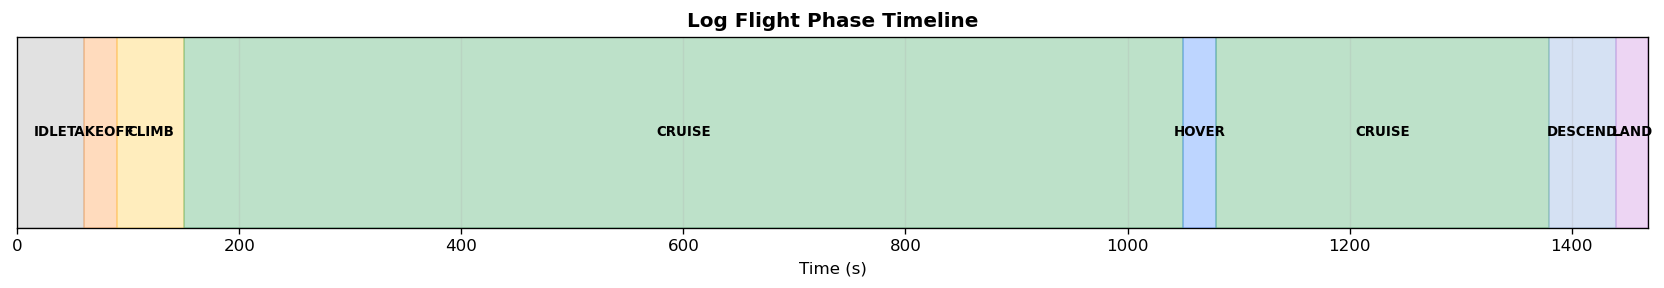

In [4]:
PHASE_COLORS = {
    'IDLE':            '#AAAAAA',
    'TAKEOFF':         '#FF9944',
    'CLIMB':           '#FFCC44',
    'CRUISE':          '#44AA66',
    'HOVER':           '#4488FF',
    'DESCEND':         '#88AADD',
    'LAND':            '#CC88DD',
    'PAYLOAD_OPS':     '#FF6688',
    'EMERGENCY':       '#FF2222',
    'VTOL_TRANSITION': '#FF6611',
    'VTOL_HOVER':      '#22AAFF',
    'FW_CRUISE':       '#00CC77',
    'FW_CLIMB':        '#AACC44',
    'FW_DESCEND':      '#99CCEE',
    'UNKNOWN':         '#BBBBBB',
}

# ── Build phase segments from log ──────────────────────────────────────────────
def extract_phase_segments(t_arr, phase_arr):
    """Return list of (phase_name, t_start, t_end) from phase label array."""
    segments = []
    if len(t_arr) == 0:
        return segments
    prev, t0 = phase_arr[0], t_arr[0]
    for ti, ph in zip(t_arr[1:], phase_arr[1:]):
        if ph != prev:
            segments.append((prev, t0, ti))
            t0, prev = ti, ph
    segments.append((prev, t0, t_arr[-1]))
    return segments

segments = extract_phase_segments(t, phases_log)

# ── Per-phase stats from log ───────────────────────────────────────────────────
phase_rows = []
for ph_name, t_start, t_end in segments:
    mask = (t >= t_start) & (t < t_end)
    if mask.sum() < 2:
        continue
    i_ph  = i_a[mask]
    v_ph  = v[mask]
    p_ph  = i_ph * v_ph
    phase_rows.append({
        'Phase':        ph_name,
        't_start (s)':  round(t_start, 1),
        't_end (s)':    round(t_end, 1),
        'Duration (s)': round(t_end - t_start, 1),
        'Mean I (A)':   round(i_ph.mean(), 2),
        'Mean V (V)':   round(v_ph.mean(), 2),
        'Mean P (W)':   round(p_ph.mean(), 1),
        'Peak P (W)':   round(p_ph.max(), 1),
    })

df_phases = pd.DataFrame(phase_rows)
print('Phase summary from log:')
print(df_phases.to_string(index=False))

# ── Phase timeline chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 2.5))
for ph_name, t_start, t_end in segments:
    color = PHASE_COLORS.get(ph_name, '#888')
    ax.axvspan(t_start, t_end, alpha=0.35, color=color, zorder=1)
    ax.text((t_start + t_end) / 2, 0.5, ph_name, ha='center', va='center',
            fontsize=8, fontweight='bold', transform=ax.get_xaxis_transform())
ax.set_xlabel('Time (s)')
ax.set_yticks([])
ax.set_title('Log Flight Phase Timeline', fontweight='bold')
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

## 4 · Build Log-Matched Mission & Run Simulation

In [5]:
# Build a MissionProfile that mirrors the log's phase structure exactly,
# using the log-measured mean power per phase as the power_override_w.

fitted_phases = []
for seq_i, row in enumerate(phase_rows):
    fitted_phases.append(MissionPhase(
        mission_id='LOG_FITTED',
        mission_name='Log-fitted mission',
        uav_config_id=UAV_ID,
        phase_seq=seq_i,
        phase_name=row['Phase'],
        phase_type=row['Phase'],
        duration_s=row['Duration (s)'],
        power_override_w=row['Mean P (W)'],   # exact log power for this phase
    ))

fitted_mission = MissionProfile(
    mission_id='LOG_FITTED',
    mission_name='Log-matched mission',
    uav_config_id=UAV_ID,
    phases=fitted_phases,
)

print(f'Fitted mission: {len(fitted_phases)} phases, '
      f'{fitted_mission.total_duration_s:.0f} s total')

# Run simulation on the fitted mission
sim = run_simulation(
    pack=pack,
    mission=fitted_mission,
    uav=uav,
    discharge_pts=db.discharge_pts,
    initial_soc_pct=soc[0] if len(soc) else 100.0,
    ambient_temp_c=AMBIENT_TEMP_C,
    dt_s=1.0,
    peukert_k=1.05,
)
print(sim.summary())

t_sim  = np.array(sim.time_s)
v_sim  = np.array(sim.voltage_v)
i_sim  = np.array(sim.current_a)
soc_sim = np.array(sim.soc_pct)

Fitted mission: 8 phases, 1469 s total
════════════════════════════════════════════════════
 Simulation: BAT_MID_6S2P × LOG_FITTED  [COMPLETED]
════════════════════════════════════════════════════
  Duration         : 1468 s  (24.5 min)
  Energy consumed  : 127.81 Wh
  Initial SoC      : 100.0 %
  Final SoC        : 34.0 %
  Min voltage      : 19.666 V
  Max current      : 30.8 A
  Peak sag total   : 1.543 V
  Peak temperature : 30.7 °C


## 5 · Log vs Simulation Overlay

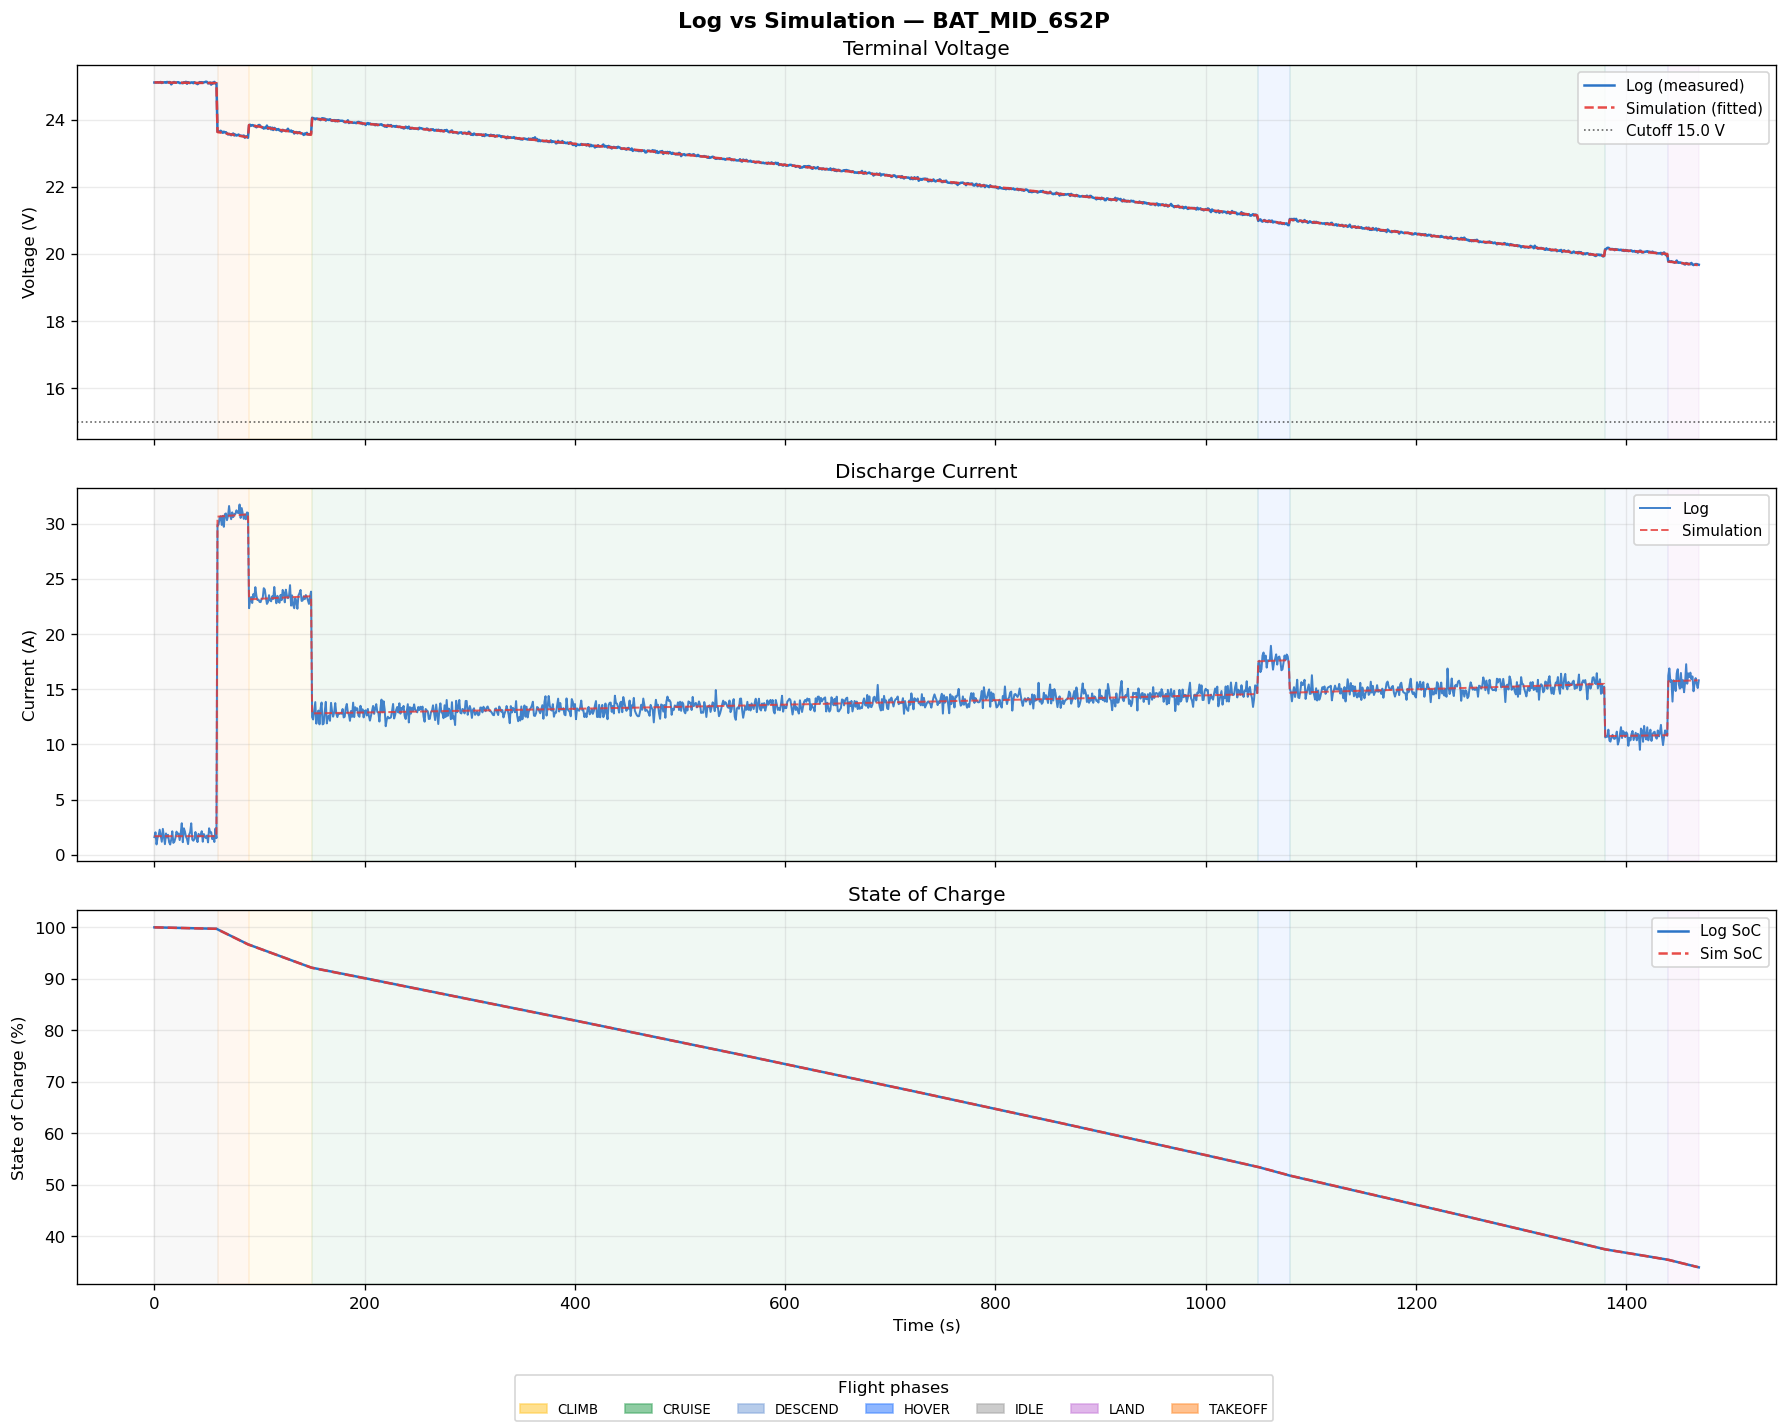

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
fig.suptitle(f'Log vs Simulation — {PACK_ID}', fontsize=13, fontweight='bold')

# ── Shade phase regions ────────────────────────────────────────────────────────
for ax in axes:
    for ph_name, t_start, t_end in segments:
        ax.axvspan(t_start, t_end, alpha=0.08,
                   color=PHASE_COLORS.get(ph_name, '#888'), zorder=0)

# ── Panel 1: Voltage ──────────────────────────────────────────────────────────
axes[0].plot(t, v, color='#1565C0', linewidth=1.5, label='Log (measured)', alpha=0.9)
axes[0].plot(t_sim, v_sim, color='#E53935', linewidth=1.5,
             linestyle='--', label='Simulation (fitted)', alpha=0.9)
axes[0].axhline(pack.pack_voltage_cutoff, color='black', linestyle=':',
                linewidth=1, label=f'Cutoff {pack.pack_voltage_cutoff:.1f} V', alpha=0.6)
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_title('Terminal Voltage')

# ── Panel 2: Current ──────────────────────────────────────────────────────────
axes[1].plot(t, i_a, color='#1565C0', linewidth=1.2, label='Log', alpha=0.8)
axes[1].plot(t_sim, i_sim, color='#E53935', linewidth=1.2,
             linestyle='--', label='Simulation', alpha=0.8)
axes[1].set_ylabel('Current (A)')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].set_title('Discharge Current')

# ── Panel 3: SoC ─────────────────────────────────────────────────────────────
axes[2].plot(t, soc, color='#1565C0', linewidth=1.5, label='Log SoC', alpha=0.9)
axes[2].plot(t_sim, soc_sim, color='#E53935', linewidth=1.5,
             linestyle='--', label='Sim SoC', alpha=0.9)
axes[2].set_ylabel('State of Charge (%)')
axes[2].set_xlabel('Time (s)')
axes[2].legend(fontsize=9, loc='upper right')
axes[2].set_title('State of Charge')

# Phase legend
patch_legend = [mpatches.Patch(color=PHASE_COLORS.get(ph, '#888'), label=ph, alpha=0.6)
                for ph in sorted(set(phases_log))]
fig.legend(handles=patch_legend, loc='lower center', ncol=min(8, len(patch_legend)),
           fontsize=8, title='Flight phases')
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('log_vs_sim_overlay.png', bbox_inches='tight')
plt.show()

## 6 · Battery Sag Analysis

Seed R estimate: 64.33 mΩ
Log  peak sag: 1.749 V  (mean: 0.912 V)
Sim  peak sag: 1.543 V  (mean: 0.654 V)


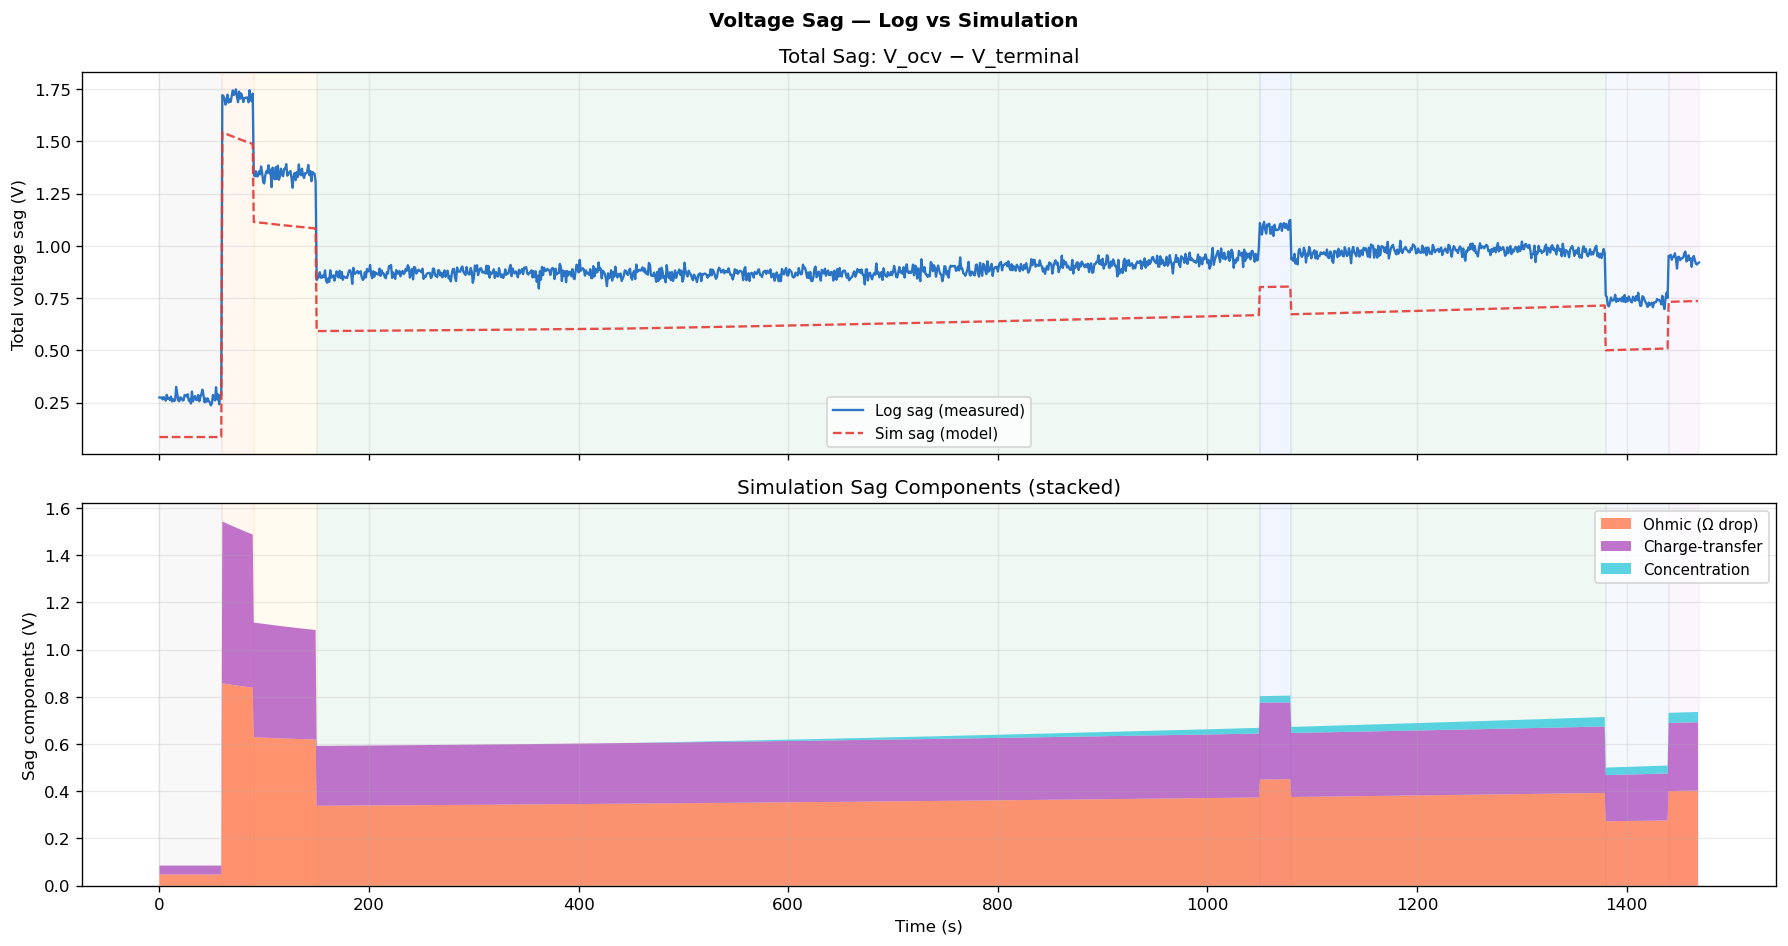

In [7]:
# ── Compute voltage sag from log ──────────────────────────────────────────────
# Sag = V_ocv_estimated - V_terminal
# V_ocv estimated by polynomial fit of (V + I*R_seed) vs SoC

def estimate_ocv(v_arr, i_arr, soc_arr, deg=4):
    """Estimate OCV(SoC) polynomial from measured V and I, return OCV array."""
    # Quick seed: polyfit V vs I slope for R estimate
    if i_arr.max() - i_arr.min() > 1.0:
        c = np.polyfit(i_arr, v_arr, 1)
        r_seed_mohm = max(5.0, -c[0] * 1000)
    else:
        r_seed_mohm = pack.internal_resistance_mohm
    v_ocv_est = v_arr + i_arr * r_seed_mohm / 1000.0
    # Smooth via polynomial in SoC
    idx = np.isfinite(v_ocv_est) & np.isfinite(soc_arr)
    coeffs = np.polyfit(soc_arr[idx], v_ocv_est[idx], deg)
    return np.polyval(coeffs, soc_arr), r_seed_mohm

v_ocv_log, r_seed = estimate_ocv(v, i_a, soc)
v_sag_log = v_ocv_log - v            # measured voltage sag [V]

v_ocv_sim = np.array(sim.dv_ohmic) + np.array(sim.dv_ct) + np.array(sim.dv_conc) + v_sim
v_sag_sim = v_ocv_sim - v_sim        # sim sag breakdown

print(f'Seed R estimate: {r_seed:.2f} mΩ')
print(f'Log  peak sag: {v_sag_log.max():.3f} V  (mean: {v_sag_log.mean():.3f} V)')
print(f'Sim  peak sag: {v_sag_sim.max():.3f} V  (mean: {v_sag_sim.mean():.3f} V)')

# ── Sag comparison chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle('Voltage Sag — Log vs Simulation', fontsize=12, fontweight='bold')

for ax in axes:
    for ph_name, t_start, t_end in segments:
        ax.axvspan(t_start, t_end, alpha=0.08,
                   color=PHASE_COLORS.get(ph_name, '#888'), zorder=0)

axes[0].plot(t, v_sag_log, color='#1565C0', linewidth=1.4, label='Log sag (measured)', alpha=0.9)
axes[0].plot(t_sim, v_sag_sim, color='#E53935', linewidth=1.4,
             linestyle='--', label='Sim sag (model)', alpha=0.9)
axes[0].set_ylabel('Total voltage sag (V)')
axes[0].legend(fontsize=9)
axes[0].set_title('Total Sag: V_ocv − V_terminal')

# Stacked sag components from simulation
dv_ohm  = np.array(sim.dv_ohmic)
dv_ct   = np.array(sim.dv_ct)
dv_conc = np.array(sim.dv_conc)
axes[1].stackplot(t_sim, dv_ohm, dv_ct, dv_conc,
                  labels=['Ohmic (Ω drop)', 'Charge-transfer', 'Concentration'],
                  colors=['#FF7043', '#AB47BC', '#26C6DA'], alpha=0.75)
axes[1].set_ylabel('Sag components (V)')
axes[1].set_xlabel('Time (s)')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].set_title('Simulation Sag Components (stacked)')

plt.tight_layout()
plt.savefig('sag_analysis.png', bbox_inches='tight')
plt.show()

## 7 · Fitted R_sag Parameter

════════════════════════════════════════════════════
  Fitted R_sag (Theil-Sen robust):
    R_sag        = 46.25 mΩ
    95% CI       = [45.42, 47.00] mΩ
    R² (sag dom) = 0.9635
  Reference values:
    Catalog IR   = 28.00 mΩ
    Sim mean R   = 45.15 mΩ
  R_sag / Catalog = 1.65x
════════════════════════════════════════════════════

Per-phase R_sag:
 Phase  R_sag (mΩ)  CI lo  CI hi  Mean I (A)  n pts
CRUISE       19.36  16.87  21.83       13.63    900


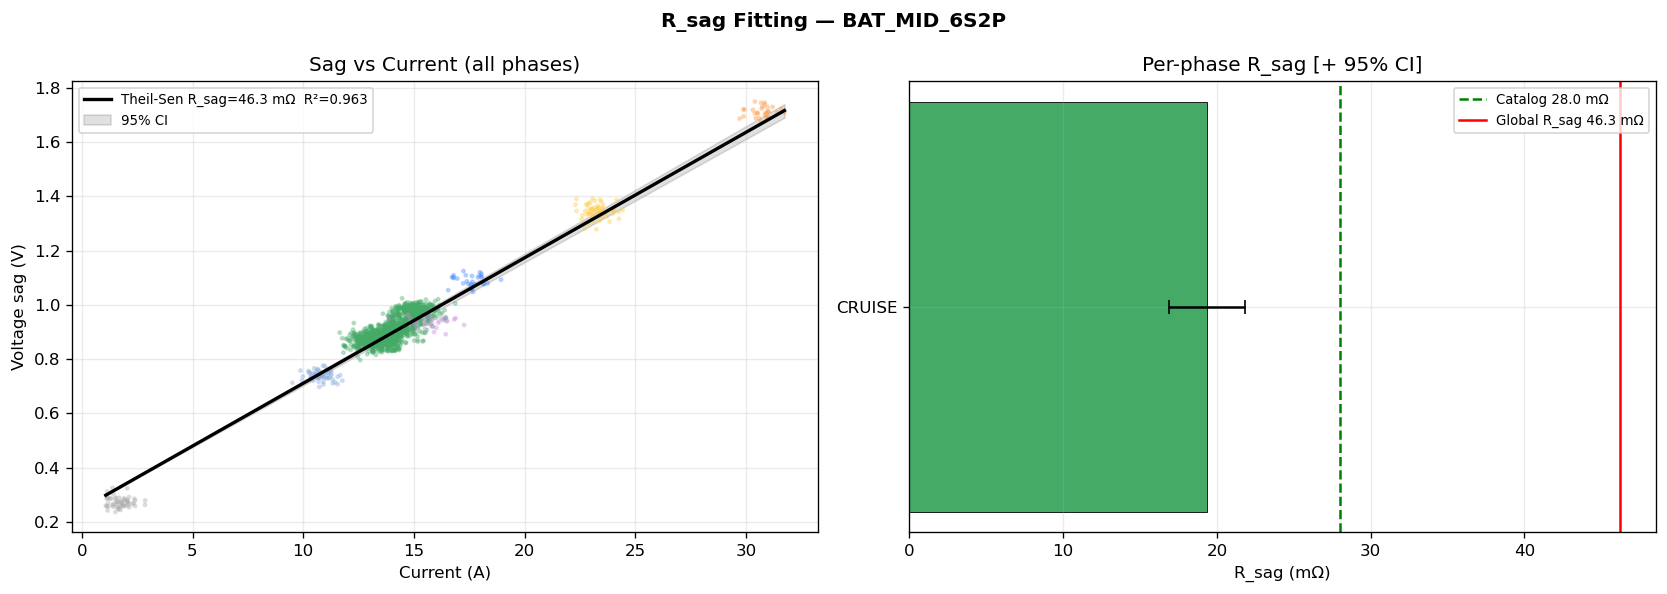

In [8]:
# ── Fit effective R_sag from log: V_sag = R_sag * I ──────────────────────────
# Use Theil-Sen robust regression to resist outliers at phase transitions.

valid = (i_a > 1.0) & np.isfinite(v_sag_log) & (v_sag_log > 0)
iv_valid   = i_a[valid]
sag_valid  = v_sag_log[valid]

res_theil  = stats.theilslopes(sag_valid, iv_valid, 0.95)
r_sag_mohm = res_theil.slope * 1000        # V/A → mΩ
r_sag_lo   = res_theil.low_slope  * 1000
r_sag_hi   = res_theil.high_slope * 1000

# R² in sag domain
sag_pred = iv_valid * res_theil.slope + res_theil.intercept
ss_res = np.sum((sag_valid - sag_pred)**2)
ss_tot = np.sum((sag_valid - sag_valid.mean())**2)
r2_sag = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

# Catalog and simulation reference
r_catalog = pack.internal_resistance_mohm
r_sim_ref  = np.mean(sim.r_total) if sim.r_total else r_catalog

print('═' * 52)
print(f'  Fitted R_sag (Theil-Sen robust):')
print(f'    R_sag        = {r_sag_mohm:.2f} mΩ')
print(f'    95% CI       = [{r_sag_lo:.2f}, {r_sag_hi:.2f}] mΩ')
print(f'    R² (sag dom) = {r2_sag:.4f}')
print(f'  Reference values:')
print(f'    Catalog IR   = {r_catalog:.2f} mΩ')
print(f'    Sim mean R   = {r_sim_ref:.2f} mΩ')
print(f'  R_sag / Catalog = {r_sag_mohm/r_catalog:.2f}x')
print('═' * 52)

# ── Per-phase R_sag ────────────────────────────────────────────────────────────
phase_rsag_rows = []
for ph_name, t_start, t_end in segments:
    mask = (t >= t_start) & (t < t_end) & (i_a > 1.0) & (v_sag_log > 0)
    if mask.sum() < 6:
        continue
    iv_ph  = i_a[mask]
    sg_ph  = v_sag_log[mask]
    if iv_ph.max() - iv_ph.min() < 0.5:
        continue
    res_ph = stats.theilslopes(sg_ph, iv_ph, 0.95)
    r_ph   = res_ph.slope * 1000
    if not (5 < r_ph < 800):
        continue
    phase_rsag_rows.append({
        'Phase':      ph_name,
        'R_sag (mΩ)': round(r_ph, 2),
        'CI lo':      round(res_ph.low_slope  * 1000, 2),
        'CI hi':      round(res_ph.high_slope * 1000, 2),
        'Mean I (A)': round(iv_ph.mean(), 2),
        'n pts':      int(mask.sum()),
    })

df_rsag = pd.DataFrame(phase_rsag_rows).sort_values('Mean I (A)')
print('\nPer-phase R_sag:')
print(df_rsag.to_string(index=False))

# ── Scatter plot: sag vs current with fitted line ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'R_sag Fitting — {PACK_ID}', fontsize=12, fontweight='bold')

# Left: full log scatter
colors_ph = [PHASE_COLORS.get(p, '#888') for p in phases_log[valid]]
axes[0].scatter(iv_valid, sag_valid, c=colors_ph, s=4, alpha=0.3, zorder=2)
i_fit = np.linspace(iv_valid.min(), iv_valid.max(), 100)
v_fit = i_fit * res_theil.slope + res_theil.intercept
axes[0].plot(i_fit, v_fit, 'k-', linewidth=2,
             label=f'Theil-Sen R_sag={r_sag_mohm:.1f} mΩ  R²={r2_sag:.3f}')
axes[0].fill_between(i_fit,
                     i_fit * res_theil.low_slope  + res_theil.intercept,
                     i_fit * res_theil.high_slope + res_theil.intercept,
                     alpha=0.12, color='black', label='95% CI')
axes[0].set_xlabel('Current (A)')
axes[0].set_ylabel('Voltage sag (V)')
axes[0].set_title('Sag vs Current (all phases)')
axes[0].legend(fontsize=8)

# Right: per-phase R_sag bar chart
if not df_rsag.empty:
    bar_colors = [PHASE_COLORS.get(p, '#888') for p in df_rsag['Phase']]
    axes[1].barh(df_rsag['Phase'], df_rsag['R_sag (mΩ)'],
                 color=bar_colors, edgecolor='black', linewidth=0.5)
    axes[1].errorbar(df_rsag['R_sag (mΩ)'], df_rsag['Phase'],
                     xerr=[df_rsag['R_sag (mΩ)'] - df_rsag['CI lo'],
                           df_rsag['CI hi'] - df_rsag['R_sag (mΩ)']],
                     fmt='none', color='black', capsize=4)
    axes[1].axvline(r_catalog, color='green', linestyle='--', linewidth=1.5,
                    label=f'Catalog {r_catalog:.1f} mΩ')
    axes[1].axvline(r_sag_mohm, color='red', linestyle='-', linewidth=1.5,
                    label=f'Global R_sag {r_sag_mohm:.1f} mΩ')
    axes[1].set_xlabel('R_sag (mΩ)')
    axes[1].set_title('Per-phase R_sag [+ 95% CI]')
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('rsag_fit.png', bbox_inches='tight')
plt.show()

## 8 · Residual Analysis (Log − Simulation)

Voltage residual (Log − Simulation):
  RMSE : 0.0200 V
  MAE  : 0.0159 V
  Bias : +0.0000 V  (+ means sim under-predicts voltage)


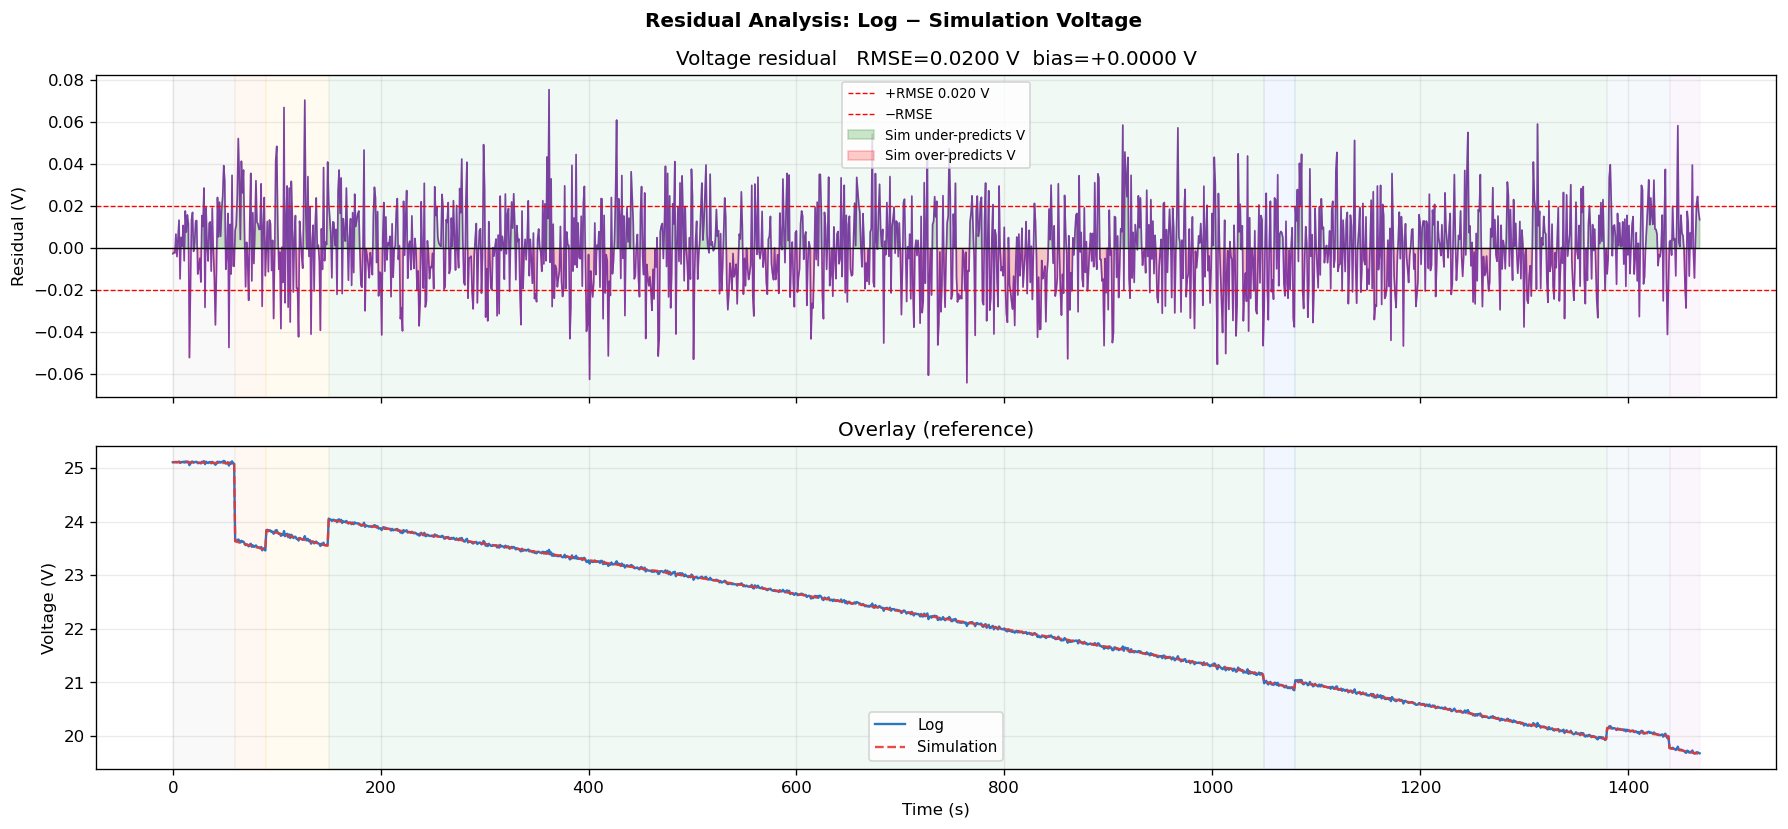


════════════════════════════════════════════════════════
  SUMMARY
════════════════════════════════════════════════════════
  Pack              : BAT_MID_6S2P
  Catalog R_ir      : 28.00 mΩ
  Fitted R_sag      : 46.25 mΩ  [45.4–47.0]
  R² (sag domain)  : 0.9635
  Voltage RMSE      : 0.0200 V
  Voltage bias      : +0.0000 V
  Log peak sag      : 1.749 V
  Sim peak sag      : 1.543 V
════════════════════════════════════════════════════════


In [9]:
# Interpolate sim onto log time axis for direct comparison
from scipy.interpolate import interp1d

f_vsim = interp1d(t_sim, v_sim, bounds_error=False, fill_value='extrapolate')
v_sim_interp = f_vsim(t)
residual = v - v_sim_interp          # log V − sim V

rmse  = np.sqrt(np.mean(residual**2))
mae   = np.mean(np.abs(residual))
bias  = np.mean(residual)

print(f'Voltage residual (Log − Simulation):')
print(f'  RMSE : {rmse:.4f} V')
print(f'  MAE  : {mae:.4f} V')
print(f'  Bias : {bias:+.4f} V  (+ means sim under-predicts voltage)')

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle('Residual Analysis: Log − Simulation Voltage', fontsize=12, fontweight='bold')

for ax in axes:
    for ph_name, t_start, t_end in segments:
        ax.axvspan(t_start, t_end, alpha=0.07,
                   color=PHASE_COLORS.get(ph_name, '#888'), zorder=0)

axes[0].plot(t, residual, color='#6A1B9A', linewidth=1.0, alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='-')
axes[0].axhline( rmse, color='red',  linewidth=0.8, linestyle='--', label=f'+RMSE {rmse:.3f} V')
axes[0].axhline(-rmse, color='red',  linewidth=0.8, linestyle='--', label=f'−RMSE')
axes[0].fill_between(t, residual, 0, where=(residual > 0), alpha=0.2, color='green',
                      label='Sim under-predicts V')
axes[0].fill_between(t, residual, 0, where=(residual < 0), alpha=0.2, color='red',
                      label='Sim over-predicts V')
axes[0].set_ylabel('Residual (V)')
axes[0].set_title(f'Voltage residual   RMSE={rmse:.4f} V  bias={bias:+.4f} V')
axes[0].legend(fontsize=8)

axes[1].plot(t, v, color='#1565C0', linewidth=1.4, label='Log', alpha=0.9)
axes[1].plot(t, v_sim_interp, color='#E53935', linewidth=1.4,
             linestyle='--', label='Simulation', alpha=0.9)
axes[1].set_ylabel('Voltage (V)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Overlay (reference)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight')
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print()
print('═' * 56)
print('  SUMMARY')
print('═' * 56)
print(f'  Pack              : {PACK_ID}')
print(f'  Catalog R_ir      : {r_catalog:.2f} mΩ')
print(f'  Fitted R_sag      : {r_sag_mohm:.2f} mΩ  [{r_sag_lo:.1f}–{r_sag_hi:.1f}]')
print(f'  R² (sag domain)  : {r2_sag:.4f}')
print(f'  Voltage RMSE      : {rmse:.4f} V')
print(f'  Voltage bias      : {bias:+.4f} V')
print(f'  Log peak sag      : {v_sag_log.max():.3f} V')
print(f'  Sim peak sag      : {v_sag_sim.max():.3f} V')
print('═' * 56)